# Seleção de Protótipos e Atributos

***

In [131]:
!pip install ucimlrepo

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from imblearn.under_sampling import CondensedNearestNeighbour, EditedNearestNeighbours

import warnings
warnings.filterwarnings('ignore')

seed = 42

## Métodos para visualização

In [133]:
#Função para visualizar uma região 2d, com duas features
def plot_2d_space(X, y, f1, f2, colors=None, markers=None):
    colors = {"M": "steelblue", "B": "darkorange"} if colors==None else colors
    markers = {"M": "s", "B": "^"} if markers==None else markers

    plt.figure()
    labels = list(y.unique())
    labels.sort()

    lines = []
    for i in labels:
        line = plt.scatter(
            X[f1][y==i],
            X[f2][y==i],
            c=colors[i],
            marker=markers[i],
            label=i,
        )

        lines.append(line)

    plt.xlabel(f1)
    plt.ylabel(f2)


    plt.legend(handles=lines)

    plt.show()

In [134]:
def percentage(train, resampled):
  excluidos = (train-resampled)
  percentage = 100 * float(excluidos)/float(train)
  return percentage

## Análise do conjunto de dados

In [135]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

dataset = pd.concat([X, y], axis=1)

In [136]:
dataset.shape

(569, 31)

In [137]:
dataset.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [138]:
dataset.columns

Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3', 'Diagnosis'],
      dtype='object')

In [139]:
dataset['Diagnosis'].value_counts()

,count
Diagnosis,
B,357
M,212


In [140]:
X = dataset.drop(['Diagnosis'], axis = 1)
y = dataset['Diagnosis']

X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (398, 30)
Shape de X_test: (171, 30)
Shape de y_train: (398,)
Shape de y_test: (171,)


**Vamos visuaizar os dados usando duas features**

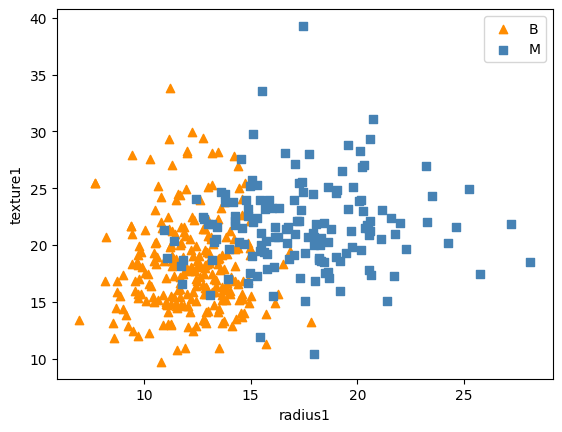

In [142]:
feature_0 = "radius1"
feature_1 = "texture1"

plot_2d_space(X_train, y_train, feature_0, feature_1)

In [143]:
y_train.value_counts()

,count
Diagnosis,
B,250
M,148


**Treinando um classificador com os valores default**

In [144]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# vamos observar cada uma das classes usando duas features..

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.91      0.99      0.95       107
           M       0.98      0.83      0.90        64

    accuracy                           0.93       171
   macro avg       0.94      0.91      0.92       171
weighted avg       0.93      0.93      0.93       171



# **Seleção de Protótipos**



## Edited Nearest Neighbours **(ENN)**

Realiza subamostragem removendo amostras cujo rótulo de classe difere da classe da maioria dos seus k vizinhos mais próximos. Atua como filtro removedor de ruídos e suavizador de limites de decisão, reduzindo a sobreposição entre as classes. Foca em limpar o conjunto de dados removendo **instâncias ruidosas**.

Como funciona:

- Para cada instância no conjunto de dados, ENN verifica seus k-vizinhos mais próximos.
    - Se a classe da instância for diferente da maioria de seus k-vizinhos, ela é removida do conjunto de dados.

Parâmetros:

- ``sampling_strategy``: *auto* é o padrão.
    - *auto*: Reamostrar todas as classes, exceto a minoritária.
    - *majority*: Reamostra apenas a classe majoritária.
    - *not minority*: Reamostra todas as classes, exceto a minoritária.
    - *not majority*: Reamostra todas as classes, exceto a majoritária.
    - *all*: Reamostra todas as classes.
    

- ``n_neighbors``: tamanho da vizinhança a ser considerado para calcular os vizinhos mais próximos. *Default*=3-NN

- ``kind_sel``: Estratégia usada para excluir amostras.
    - *all*: Todos os vizinhos devem ser da mesma classe da amostra para que ela não seja excluída.
    - *mode*: A maioria dos vizinhos deve ser da mesma classe da amostra para que ela não seja excluída.

A implementação é detalhada [aqui](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.EditedNearestNeighbours.html)

In [145]:
enn = EditedNearestNeighbours()
enn.get_params()

{'kind_sel': 'all',
 'n_jobs': None,
 'n_neighbors': 3,
 'sampling_strategy': 'auto'}

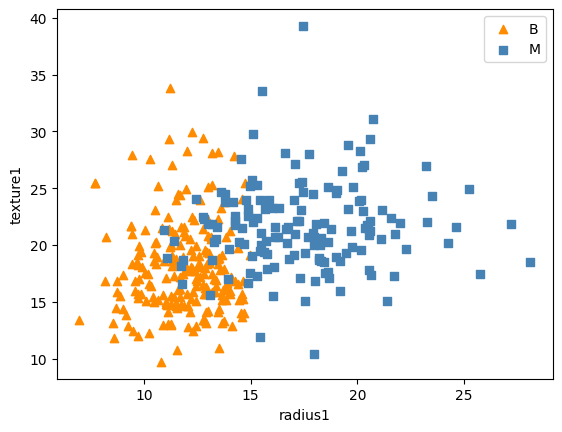

In [146]:
X_train_enn, y_train_enn = enn.fit_resample(X_train, y_train)

#Classes filtradas usando ENN
plot_2d_space(X_train_enn, y_train_enn, feature_0, feature_1)

In [147]:
y_train_enn.value_counts()

,count
Diagnosis,
B,217
M,148


In [148]:
print("Porcentagem de redução: %.2f%%" % (percentage(y_train.count(), y_train_enn.count())))

Porcentagem de redução: 8.29%


In [149]:
model = KNeighborsClassifier()

model.fit(X_train_enn, y_train_enn)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.93      0.98      0.95       107
           M       0.97      0.88      0.92        64

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



## Condensed Nearest Neighbour **(CNN)**

Remove amostras de classe majoritária que estão longe do limite de decisão e retem aquelas que estão próximas do limite de decisão. Então, o objetivo é selecionar um subconjunto de amostras de classe majoritária que estão próximas do limite de decisão. O CNN foca em reduzir o conjunto de dados mantendo a capacidade de classificação, removendo **instâncias redundantes**.

 [Os passos são os seguintes:](https://www.kaggle.com/discussions/general/426819)

1. Um subconjunto aleatório é selecionado das amostras da classe majoritária.
2. Para cada amostra de classe majoritária não incluída no subconjunto, são identificados os vizinhos mais próximos de ambas as classes.
3. Se a amostra da classe majoritária for mal classificada (ou seja, pertencer à classe minoritária de acordo com seus vizinhos mais próximos), ela será adicionada ao subconjunto.
4. O processo continua até que nenhuma amostra da classe majoritária possa ser adicionada ao subconjunto.

**Parâmetros**:

- `sampling_strategy`: *auto* é o padrão.
    - *auto*: Reamostrar todas as classes, exceto a minoritária.
    - *majority*: Reamostra apenas a classe majoritária.
    - *not minority*: Reamostra todas as classes, exceto a minoritária.
    - *not majority*: Reamostra todas as classes, exceto a majoritária.
    - *all*: Reamostra todas as classes.
- `n_neighbors`: tamanho da vizinhança a ser considerado para calcular os vizinhos mais próximos. *Default*` = 'None' (1-NN)

- `random_state`: controla a randomização do algoritmo.

- `n_seeds_S`: Número de amostras a extrair para construir o conjunto S. Padrão = 1.

A implementação é detalhada [aqui](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.CondensedNearestNeighbour.html)

In [150]:
cnn = CondensedNearestNeighbour(random_state=seed)
cnn.get_params()

{'n_jobs': None,
 'n_neighbors': None,
 'n_seeds_S': 1,
 'random_state': 42,
 'sampling_strategy': 'auto'}

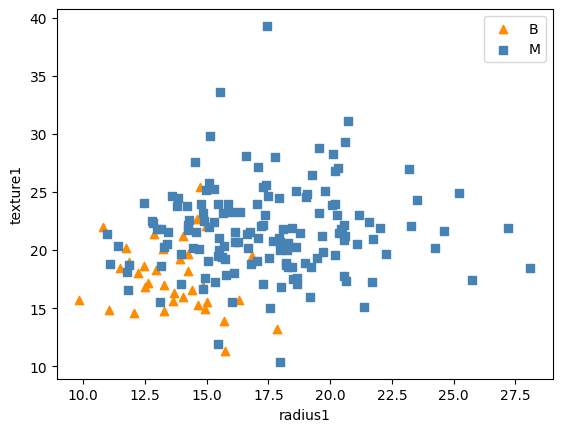

In [151]:
X_train_cnn, y_train_cnn = cnn.fit_resample(X_train, y_train)

#Classes filtradas usando CNN
plot_2d_space(X_train_cnn, y_train_cnn, feature_0, feature_1)

In [152]:
y_train_cnn.value_counts()

,count
Diagnosis,
M,148
B,36


In [153]:
model = KNeighborsClassifier()

model.fit(X_train_cnn, y_train_cnn)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.92      0.98      0.95       107
           M       0.96      0.86      0.91        64

    accuracy                           0.94       171
   macro avg       0.94      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171



In [154]:
print("Porcentegem de redução: %.2f%%" % (percentage(y_train.count(), y_train_cnn.count())))

Porcentegem de redução: 53.77%


# **Seleção de Atributos**

## **Filters**

## Limiar de Variância

O limiar de variância é o método mais simples de seleção de atributos (features). Caso a feature não tenha determinada variância, ela deve ser removida.

In [155]:
from sklearn.feature_selection import VarianceThreshold

filter_variance = VarianceThreshold(0.7)
X_filtered = filter_variance.fit_transform(X)

# quantas features conseguimos remover?
print("Número inicial de features: %d" %(X.shape[1]))
print("Features selecionadas: %d" %(X_filtered.shape[1]))

Número inicial de features: 30
Features selecionadas: 10


In [156]:
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.3, stratify=y, random_state=42)

In [157]:
model = KNeighborsClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.91      0.99      0.95       107
           M       0.98      0.83      0.90        64

    accuracy                           0.93       171
   macro avg       0.94      0.91      0.92       171
weighted avg       0.93      0.93      0.93       171



# **Wrapper** - Recursive Feature Elimination (RFE)

Aqui, o processo de escolha de features depende de outros classificadores. Escolhemos um classificador linear, onde os coeficientes, ou medida de importância interna ao classificador, são utilizados para escolha das features mais importantes. Esse método é feito de forma recursiva, onde podemos controlar a quantidade de passos.

In [158]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC

X = dataset.drop(['Diagnosis'], axis = 1)
y = dataset['Diagnosis']

base_estimator = SVC(kernel="linear")
rfe = RFE(base_estimator, n_features_to_select=2, step=1)
X_filtered = rfe.fit_transform(X, y)

print(X_filtered.shape)

(569, 2)


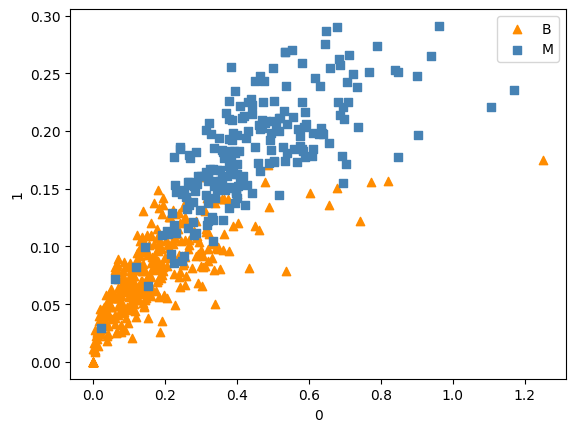

In [159]:
# visualizando as features selecionadas
df = pd.DataFrame(X_filtered, columns=[0, 1])
plot_2d_space(df, y, 0, 1)

In [160]:
#Nomes das features vistas durante o ajuste
ft_names = rfe.feature_names_in_
print(ft_names)

['radius1' 'texture1' 'perimeter1' 'area1' 'smoothness1' 'compactness1'
 'concavity1' 'concave_points1' 'symmetry1' 'fractal_dimension1' 'radius2'
 'texture2' 'perimeter2' 'area2' 'smoothness2' 'compactness2' 'concavity2'
 'concave_points2' 'symmetry2' 'fractal_dimension2' 'radius3' 'texture3'
 'perimeter3' 'area3' 'smoothness3' 'compactness3' 'concavity3'
 'concave_points3' 'symmetry3' 'fractal_dimension3']


In [161]:
#Máscara de features selecionadas.
print(rfe.support_) # retorna um array booleano indicando quais features foram selecionadas como importantes
print("\nFeatures selecionadas:")
print(ft_names[rfe.support_])

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False  True  True False False]

Features selecionadas:
['concavity3' 'concave_points3']


In [162]:
#Ranking
rfe.ranking_

array([ 7, 20, 15, 29, 12, 11,  8,  9, 10, 26, 24,  5, 13, 21, 22, 18, 17,
       19, 27, 25,  6, 14, 23, 28,  4,  3,  1,  1,  2, 16])

----------------------------

In [163]:
dataset.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [164]:
X = dataset[['concavity3','concave_points3']]
y = dataset['Diagnosis']

In [165]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)
X_train.shape

(398, 2)

In [166]:
model = KNeighborsClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.93      0.93      0.93       107
           M       0.88      0.88      0.88        64

    accuracy                           0.91       171
   macro avg       0.90      0.90      0.90       171
weighted avg       0.91      0.91      0.91       171

